In [25]:
pip install qutip

Note: you may need to restart the kernel to use updated packages.


In [26]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [27]:
import numpy as np
from pylab import *
import matplotlib.pyplot as plt
from qutip import *
import math
import itertools
import networkx as nx

## Qu-Quarts

In [28]:
# Define single qubit basis states
qubit_0 = basis(2, 0)  # |0⟩
qubit_1 = basis(2, 1)  # |1⟩

# Create the 4 basis states of the ququart
ququart_00 = tensor(qubit_0, qubit_0)  # |00⟩
ququart_01 = tensor(qubit_0, qubit_1)  # |01⟩
ququart_10 = tensor(qubit_1, qubit_0)  # |10⟩
ququart_11 = tensor(qubit_1, qubit_1)  # |11⟩

print("Ququart basis states:\n")
for i, state in enumerate([ququart_00, ququart_01, ququart_10, ququart_11]):
    print(f"|{i:02b}⟩ = {state.dag()}")

Ququart basis states:

|00⟩ = Quantum object: dims=[[1], [2, 2]], shape=(1, 4), type='bra', dtype=Dense
Qobj data =
[[1. 0. 0. 0.]]
|01⟩ = Quantum object: dims=[[1], [2, 2]], shape=(1, 4), type='bra', dtype=Dense
Qobj data =
[[0. 1. 0. 0.]]
|10⟩ = Quantum object: dims=[[1], [2, 2]], shape=(1, 4), type='bra', dtype=Dense
Qobj data =
[[0. 0. 1. 0.]]
|11⟩ = Quantum object: dims=[[1], [2, 2]], shape=(1, 4), type='bra', dtype=Dense
Qobj data =
[[0. 0. 0. 1.]]


In [29]:
#Making a QuQuart

quart_state1 = Qobj([[1, 0, 1, 0]]) # |bra>
quart_state2 = Qobj([[1, 1, 0, 0]]).trans() # <ket|


print(quart_state1)
print(quart_state2)

print(f"\nInner Product: {quart_state1 * quart_state2}")
print(f"\nOuter Product: {quart_state2 * quart_state1}")

Quantum object: dims=[[1], [4]], shape=(1, 4), type='bra', dtype=Dense
Qobj data =
[[1. 0. 1. 0.]]
Quantum object: dims=[[4], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [1.]
 [0.]
 [0.]]

Inner Product: (1+0j)

Outer Product: Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=CSR, isherm=False
Qobj data =
[[1. 0. 1. 0.]
 [1. 0. 1. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


## Control: Brute Force Strategy w/ 4-Qubit Systems

In [30]:
                    # --------------------------------------------------------------------------------- #
                    # BRUTE FORCE STRATEGY (OPTIMAL FOR 4-QUBIT SYSTEMS, WILL FAIL PAST THIS THRESHOLD) #
                    # --------------------------------------------------------------------------------- #

# ----------------------- 1. CREATING INTERSECTION GRAPH --------------------------------#

# Graph representation is as follows:
# - Nodes: represent invidiual qubits
# - Edges: represent 2-qubit gates, w/ edge weight representing # of gates between those qubits in total

G = nx.Graph()


qubits = ['q0', 'q1', 'q2', 'q3'] # node list (can be modified based on a given graph)
# defining qubit-qubit intersections w/ format (qubit A, qubit B, # gates acting on both)
interactions = [
    ('q0', 'q1', 4),
    ('q1', 'q2', 0),
    ('q2', 'q3', 3),
    ('q0', 'q3', 6)
]

G.add_nodes_from(qubits)
for q1, q2, weight in interactions:
    G.add_edge(q1, q2, weight=weight)

# ----------------------- 2. GENERATING ALL VALID MAPPINGS -------------------------------- #

def generate_pairings(qubits): # fctn generates all unique qubit mappings (pairs of size 2 in case of 4-qubit system)
    pairings = []

    for pair in itertools.combinations(qubits, 2):
        remaining = [q for q in qubits if q not in pair]
        second_pair = tuple(remaining)
        pairing = tuple(sorted((tuple(sorted(pair)), tuple(sorted(second_pair))))) # sort to avoid duplicates
        pairings.append(pairing)
    return list(set(pairings))
    
pairings = generate_pairings(qubits)

# ----------------------- 3. COUNT CROSS-QUQUART GATES FOR EACH MAPPING -------------------------------- #

def cross_ququart_cost(pairing, graph): # fctn that computes # of cross-ququart gates

    # Map each qubit to a ququart ID (2 total ququarts for 4-qubit system; IDs = [0, 1])
    ququart_map = {}
    for i, ququart in enumerate(pairing):
        for qubit in ququart:
            ququart_map[qubit] = i
    cost = 0

    for q1, q2, data in graph.edges(data=True):
        # If qubits belong to different ququarts → cross gate
        if ququart_map[q1] != ququart_map[q2]:
            cost += data['weight']
            
    return cost

# ----------------------- 4. CALCULATE OPTIMAL MAPPING -------------------------------- #

best_pairing = None
best_cost = float('inf') # 'inf' = +infinity (best-cost default)

for pairing in pairings:
    cost = cross_ququart_cost(pairing, G)
    print(f"Pairing {pairing} → Cross-ququart gates: {cost}")

    if cost < best_cost:
        best_cost = cost
        best_pairing = pairing

print("\n Optimal ququart mapping:")
print(best_pairing)
print(f"Minimum cross-ququart gates: {best_cost}")


Pairing (('q0', 'q1'), ('q2', 'q3')) → Cross-ququart gates: 6
Pairing (('q0', 'q3'), ('q1', 'q2')) → Cross-ququart gates: 7
Pairing (('q0', 'q2'), ('q1', 'q3')) → Cross-ququart gates: 13

 Optimal ququart mapping:
(('q0', 'q1'), ('q2', 'q3'))
Minimum cross-ququart gates: 6


## Test: Kernighan-Lin Graph Partitioning Strategy

In [31]:
from networkx.algorithms.community import kernighan_lin_bisection

# --------------------------------------------------------------------------------- #
# KERNIGHAN–LIN GRAPH PARTITIONING STRATEGY (SCALABLE, HEURISTIC, N-QUBIT SYSTEMS)     #
# --------------------------------------------------------------------------------- #

# ----------------------- 0. CONFIGURATION ------------------------------------------ #

NUM_QUBITS = 8                                   # total number of qubits (scales to hundreds)
QUBITS = [f"q{i}" for i in range(NUM_QUBITS)]    # node labels

# ----------------------- 1. CREATING INTERACTION GRAPH ----------------------------- #

# Graph representation:
# - Nodes: represent individual qubits
# - Edges: represent 2-qubit gates
# - Edge weight: total number of gates between those qubits

G = nx.Graph()
G.add_nodes_from(QUBITS)

# create intersections array (allowed to create more dense, conflicting interaction structure than was possible w/ brute force)
interactions = [
    ('q0', 'q1', 8),
    ('q1', 'q2', 6),
    ('q2', 'q3', 7),
    ('q4', 'q5', 9),
    ('q5', 'q6', 6),
    ('q6', 'q7', 8),
    ('q0', 'q4', 4),
    ('q1', 'q5', 5),
    ('q2', 'q6', 4),
    ('q3', 'q7', 5),
    ('q0', 'q6', 3),
    ('q1', 'q7', 2),
    ('q3', 'q4', 3),
    ('q0', 'q2', 5),
    ('q1', 'q3', 4),
    ('q4', 'q6', 5),
    ('q5', 'q7', 4),
    ('q0', 'q3', 2),
    ('q2', 'q5', 2),
    ('q1', 'q4', 1),
    ('q3', 'q6', 1),
]

# Add weighted edges to graph
for q1, q2, weight in interactions:
    G.add_edge(q1, q2, weight=weight)

# ----------------------- 2. BALANCED GRAPH PARTITIONING ----------------------------- #

# Apply Kernighan–Lin heuristic:
# - Produces two equal-size partitions
# - Minimizes weighted edge cut between partitions
# - Heuristic (not globally optimal, but scalable)

partition_A, partition_B = kernighan_lin_bisection(
    G,
    weight='weight'
)

# ----------------------- 3. COUNT CROSS-QUQUART GATES ------------------------------- #

def cross_ququart_cost(graph, A, B): # computes total # of gates acting across ququarts
    cost = 0

    for u, v, data in graph.edges(data=True):
        # Edge contributes if it crosses the partition
        if (u in A and v in B) or (u in B and v in A):
            cost += data['weight']

    return cost

cost = cross_ququart_cost(G, partition_A, partition_B)

# ----------------------- 4. OUTPUT PARTITION RESULTS -------------------------------- #

print("\n================= PARTITION RESULT =================")
print("Ququart 0:", sorted(partition_A))
print("Ququart 1:", sorted(partition_B))
print("Cross-ququart gate cost:", cost)
print("====================================================")



================= PARTITION RESULT =================
Ququart 0: ['q4', 'q5', 'q6', 'q7']
Ququart 1: ['q0', 'q1', 'q2', 'q3']
Cross-ququart gate cost: 30


## Test: Three Algorithm Aggregate Version


================ RANDOM CIRCUIT ================
Qubits: 14
Total 2-qubit gates: 38
Distinct interacting pairs: 32

================ RESULTS =================

--- Kernighan-Lin ---
Cut Cost: 37
Partition A: {'q1', 'q4', 'q9', 'q11', 'q12', 'q10', 'q13'}
Partition B: {'q2', 'q8', 'q6', 'q5', 'q3', 'q0', 'q7'}


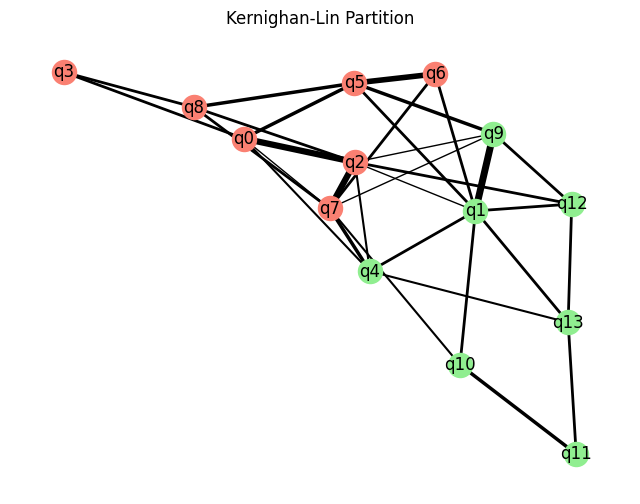


--- Spectral ---
Cut Cost: 64
Partition A: {'q1', 'q2', 'q10', 'q0', 'q11', 'q12', 'q13'}
Partition B: {'q8', 'q5', 'q3', 'q7', 'q4', 'q6', 'q9'}


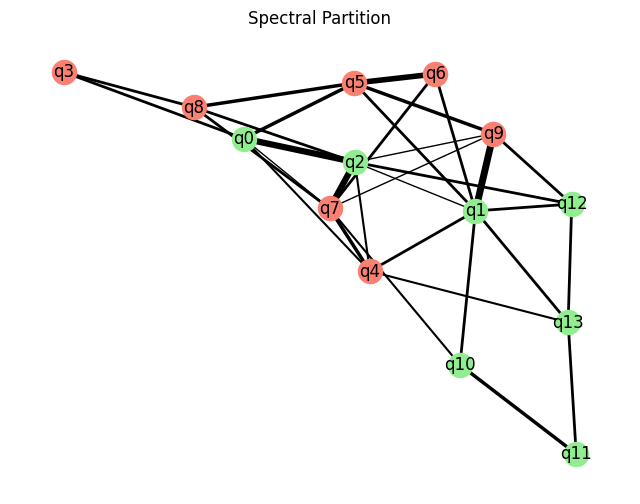


--- Fiduccia-Mattheyses ---
Cut Cost: 63
Partition A: {'q1', 'q2', 'q0', 'q7', 'q9', 'q12', 'q13'}
Partition B: {'q8', 'q5', 'q3', 'q10', 'q4', 'q6', 'q11'}


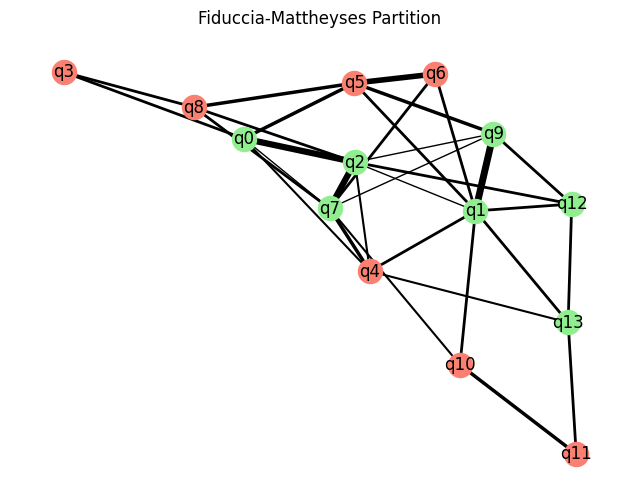


Best Algorithm: Kernighan-Lin
Best Cut Cost: 37


In [36]:
# =============================================================================
# LOCKED QUQUART MAPPING EXPERIMENT
# (No NumPy sum conflicts. No generator ambiguity.)
# Algorithms:
#   - Kernighan–Lin
#   - Spectral
#   - Fiduccia–Mattheyses
# =============================================================================

import random
import builtins
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# =============================================================================
# GATE WEIGHTS
# =============================================================================

GATE_WEIGHTS = {
    "CNOT": 3,
    "CZ": 2,
    "SWAP": 5,
    "iSWAP": 4
}

# =============================================================================
# RANDOM CIRCUIT GENERATION
# =============================================================================

def generate_random_circuit(min_qubits=6, max_qubits=14,
                            min_gates=20, max_gates=60):

    n = random.choice([q for q in range(min_qubits, max_qubits + 1) if q % 2 == 0])
    qubits = [f"q{i}" for i in range(n)]

    interactions = defaultdict(lambda: defaultdict(int))
    num_gates = random.randint(min_gates, max_gates)

    for _ in range(num_gates):
        q1, q2 = random.sample(qubits, 2)
        gate = random.choice(list(GATE_WEIGHTS.keys()))
        key = tuple(sorted((q1, q2)))
        interactions[key][gate] += 1

    return qubits, interactions


# =============================================================================
# BUILD INTERACTION GRAPH
# =============================================================================

def build_interaction_graph(qubits, interactions):

    G = nx.Graph()
    G.add_nodes_from(qubits)

    for (q1, q2), gate_dict in interactions.items():

        # 🔒 Force builtin sum + force list conversion
        weighted_terms = [
            GATE_WEIGHTS[g] * c
            for g, c in gate_dict.items()
        ]

        weight = builtins.sum(weighted_terms)

        G.add_edge(q1, q2, weight=weight)

    return G


# =============================================================================
# CUT COST
# =============================================================================

def cut_cost(graph, A, B):

    weights = [
        data["weight"]
        for u, v, data in graph.edges(data=True)
        if (u in A and v in B) or (u in B and v in A)
    ]

    return builtins.sum(weights)


# =============================================================================
# SPECTRAL PARTITIONING
# =============================================================================

def spectral_partition(graph):

    L = nx.laplacian_matrix(graph, weight="weight").todense()
    eigenvalues, eigenvectors = np.linalg.eigh(L)

    fiedler_vector = np.array(eigenvectors[:, 1]).flatten()
    nodes = list(graph.nodes())

    A, B = set(), set()

    for i, node in enumerate(nodes):
        if fiedler_vector[i] >= 0:
            A.add(node)
        else:
            B.add(node)

    # Enforce balance strictly
    if abs(len(A) - len(B)) > 1:
        nodes_sorted = sorted(nodes)
        half = len(nodes_sorted) // 2
        A = set(nodes_sorted[:half])
        B = set(nodes_sorted[half:])

    return A, B


# =============================================================================
# KERNIGHAN–LIN
# =============================================================================

def kernighan_lin_partition(graph):

    nodes = list(graph.nodes())
    random.shuffle(nodes)
    half = len(nodes) // 2
    initial = (set(nodes[:half]), set(nodes[half:]))

    A, B = nx.algorithms.community.kernighan_lin_bisection(
        graph,
        partition=initial,
        weight="weight"
    )

    return set(A), set(B)


# =============================================================================
# FIDUCCIA–MATTHEYSES (Simplified Balanced Version)
# =============================================================================

def fiduccia_mattheyses_partition(graph, max_passes=5):

    nodes = list(graph.nodes())
    random.shuffle(nodes)
    half = len(nodes) // 2

    A = set(nodes[:half])
    B = set(nodes[half:])

    for _ in range(max_passes):

        improved = False

        for node in list(nodes):

            current_cost = cut_cost(graph, A, B)

            if node in A and len(A) > len(B):
                A.remove(node)
                B.add(node)
                new_cost = cut_cost(graph, A, B)
                if new_cost < current_cost:
                    improved = True
                else:
                    B.remove(node)
                    A.add(node)

            elif node in B and len(B) > len(A):
                B.remove(node)
                A.add(node)
                new_cost = cut_cost(graph, A, B)
                if new_cost < current_cost:
                    improved = True
                else:
                    A.remove(node)
                    B.add(node)

        if not improved:
            break

    return A, B


# =============================================================================
# VISUALIZATION
# =============================================================================

def plot_partition(graph, A, B, title):

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(graph, seed=42)

    nx.draw_networkx_nodes(graph, pos, nodelist=list(A), node_color='lightgreen')
    nx.draw_networkx_nodes(graph, pos, nodelist=list(B), node_color='salmon')

    nx.draw_networkx_edges(
        graph,
        pos,
        width=[data["weight"] / 2 for _, _, data in graph.edges(data=True)]
    )

    nx.draw_networkx_labels(graph, pos)
    plt.title(title)
    plt.axis("off")
    plt.show()


# =============================================================================
# RUN EXPERIMENT
# =============================================================================

def run_experiment():

    qubits, interactions = generate_random_circuit()
    graph = build_interaction_graph(qubits, interactions)

    print("\n================ RANDOM CIRCUIT ================")
    print("Qubits:", len(qubits))

    # 🔒 Explicit builtin sum + force list
    gate_counts = [
        builtins.sum(list(d.values()))
        for d in interactions.values()
    ]

    total_gates = builtins.sum(gate_counts)

    print("Total 2-qubit gates:", total_gates)
    print("Distinct interacting pairs:", len(interactions))
    print("================================================")

    results = {}

    A_kl, B_kl = kernighan_lin_partition(graph)
    results["Kernighan-Lin"] = (cut_cost(graph, A_kl, B_kl), A_kl, B_kl)

    A_sp, B_sp = spectral_partition(graph)
    results["Spectral"] = (cut_cost(graph, A_sp, B_sp), A_sp, B_sp)

    A_fm, B_fm = fiduccia_mattheyses_partition(graph)
    results["Fiduccia-Mattheyses"] = (cut_cost(graph, A_fm, B_fm), A_fm, B_fm)

    print("\n================ RESULTS =================")

    for name, (score, A, B) in results.items():
        print(f"\n--- {name} ---")
        print("Cut Cost:", score)
        print("Partition A:", A)
        print("Partition B:", B)
        plot_partition(graph, A, B, f"{name} Partition")

    best = min(results, key=lambda k: results[k][0])

    print("\n===========================================")
    print("Best Algorithm:", best)
    print("Best Cut Cost:", results[best][0])
    print("===========================================")

    return results


# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    run_experiment()


## Test: Three Algorithm Aggregate Version